# Ejercicio Regression Tree
Son datos de temperaturas tomados de la ciudad de Seattle. El objetivo es intentar predecir lo mejor posible la máxima temperatura (columna `actual`) que alcanzaremos al día siguiente. Para ello contaremos con temperaturas de los dos días anteriores, históricos de máximas temperaturas y un amigo bastante chapas que te da su predicción del tiempo cada día.

**Resumen de datos**:
* year: 2016 for all data points
* month: number for month of the year
* day: number for day of the year
* week: day of the week as a character string
* temp_2: max temperature 2 days prior
* temp_1: max temperature 1 day prior
* average: historical average max temperature
* actual: max temperature measurement
* friend: your friend’s prediction, a random number between 20 below the average and 20 above the average


### 1. Importa el csv "temps.csv"

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("data/temps.csv")
df

,year,month,day,week,temp_2,temp_1,average,actual,friend
0,2016,1,1,Fri,45,45,45.6,45,29
1,2016,1,2,Sat,44,45,45.7,44,61
2,2016,1,3,Sun,45,44,45.8,41,56
3,2016,1,4,Mon,44,41,45.9,40,53
4,2016,1,5,Tues,41,40,46.0,44,41
...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,47
344,2016,12,28,Wed,42,47,45.3,48,58
345,2016,12,29,Thurs,47,48,45.3,48,65
346,2016,12,30,Fri,48,48,45.4,57,42


### 2. Realiza un análisis exploratorio junto con un Feature Engineering

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     348 non-null    int64  
 1   month    348 non-null    int64  
 2   day      348 non-null    int64  
 3   week     348 non-null    str    
 4   temp_2   348 non-null    int64  
 5   temp_1   348 non-null    int64  
 6   average  348 non-null    float64
 7   actual   348 non-null    int64  
 8   friend   348 non-null    int64  
dtypes: float64(1), int64(7), str(1)
memory usage: 24.6 KB


In [4]:
df.describe()

,year,month,day,temp_2,temp_1,average,actual,friend
count,348.0,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,2016.0,6.477011,15.514368,62.652299,62.701149,59.760632,62.543103,60.034483
std,0.0,3.498380,8.772982,12.165398,12.120542,10.527306,11.794146,15.626179
min,2016.0,1.000000,1.000000,35.000000,35.000000,45.100000,35.000000,28.000000
25%,2016.0,3.000000,8.000000,54.000000,54.000000,49.975000,54.000000,47.750000
50%,2016.0,6.000000,15.000000,62.500000,62.500000,58.200000,62.500000,60.000000
75%,2016.0,10.000000,23.000000,71.000000,71.000000,69.025000,71.000000,71.000000
max,2016.0,12.000000,31.000000,117.000000,117.000000,77.400000,92.000000,95.000000


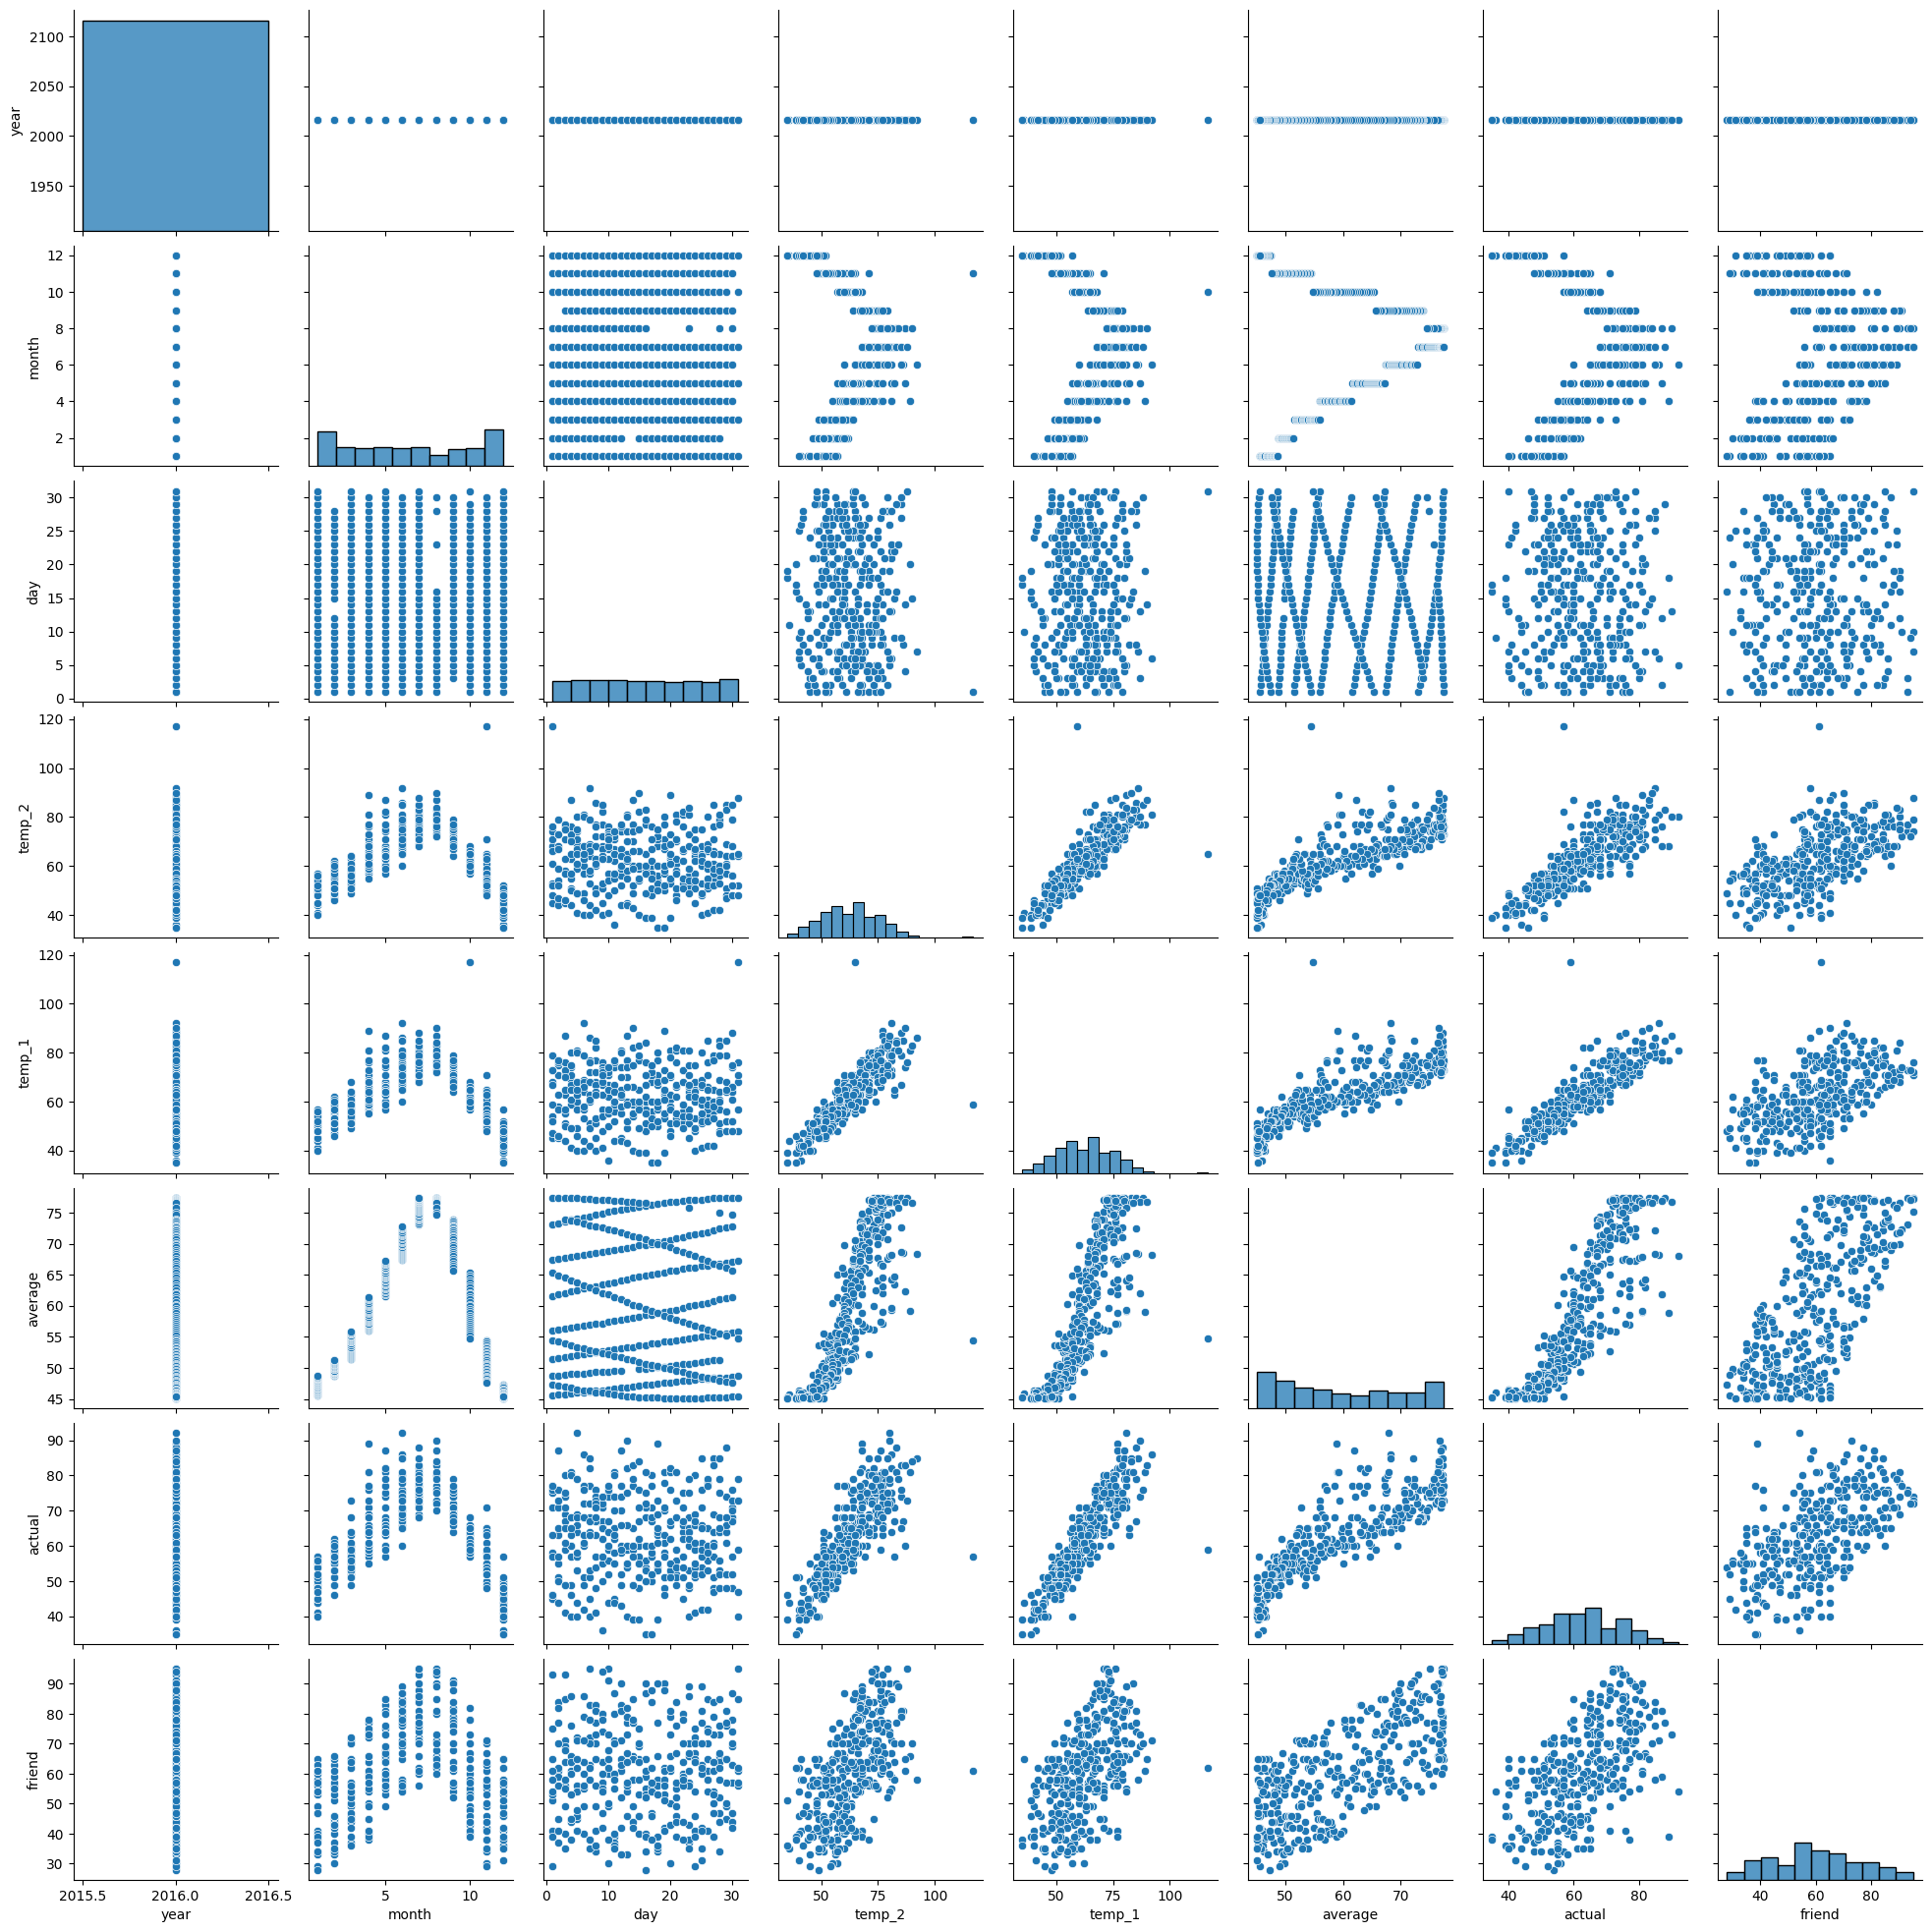

In [5]:
sns.pairplot(df);

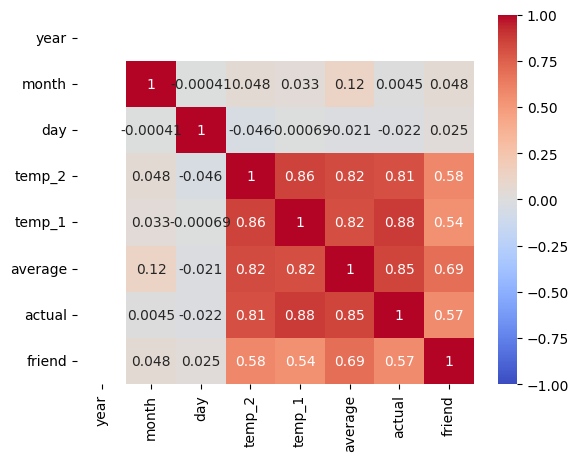

In [6]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", vmin=-1);

Hacemos un poco de Feature Engineering

In [7]:
df.head(7)

,year,month,day,week,temp_2,temp_1,average,actual,friend
0,2016,1,1,Fri,45,45,45.6,45,29
1,2016,1,2,Sat,44,45,45.7,44,61
2,2016,1,3,Sun,45,44,45.8,41,56
3,2016,1,4,Mon,44,41,45.9,40,53
4,2016,1,5,Tues,41,40,46.0,44,41
5,2016,1,6,Wed,40,44,46.1,51,40
6,2016,1,7,Thurs,44,51,46.2,45,38


**Tendencias de los días anteriores.** La temperatura muchas veces tiene una inercia térmica: si sube varios días seguidos, es más probable que siga subiendo.

In [8]:
# Tendencia de los dos días anteriores
df['temp_diff_1'] = df['temp_1'] - df['temp_2']

Las temperaturas real no dependen solo de los días previos, sino de una cierta estacionalidad.
Un 25°C en enero no es lo mismo que en julio, que es más habitual.

In [9]:
# Calculamos diferencia de la temperatura respecto al máximo histórico
df['temp_actual_avg'] = df['temp_1'] - df['average']

Relacionamos mes con la temperatura para tener esto en cuenta.

In [10]:
df['temp_month'] = df['temp_1'] * df['month']
df['temp_actavg_month'] = df['temp_actual_avg'] * df['month']

In [11]:
# El amigo suele equivocarse siempre igual?
df['error_amigo'] = df['friend'] - df['average']

Predicción de nuestro colega no nos sirve para nada. De promedio se equivoca 9.81ºC y los errores de sus predicciones están muy dispersas

Días de la semana

In [12]:
pd.get_dummies(df['week'])

,Fri,Mon,Sat,Sun,Thurs,Tues,Wed
0,True,False,False,False,False,False,False
1,False,False,True,False,False,False,False
2,False,False,False,True,False,False,False
3,False,True,False,False,False,False,False
4,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...
343,False,False,False,False,False,True,False
344,False,False,False,False,False,False,True
345,False,False,False,False,True,False,False
346,True,False,False,False,False,False,False


Encodeamos días

In [5]:
# Mapeo ordenado de días
weekday_dic = {
    'Mon': 1,
    'Tues': 2,
    'Wed': 3,
    'Thurs': 4,
    'Fri': 5,
    'Sat': 6,
    'Sun': 7
}

df['week_num'] = df['week'].map(weekday_dic)

In [6]:
df.head(7)

,year,month,day,week,temp_2,temp_1,average,actual,friend,week_num
0,2016,1,1,Fri,45,45,45.6,45,29,5
1,2016,1,2,Sat,44,45,45.7,44,61,6
2,2016,1,3,Sun,45,44,45.8,41,56,7
3,2016,1,4,Mon,44,41,45.9,40,53,1
4,2016,1,5,Tues,41,40,46.0,44,41,2
5,2016,1,6,Wed,40,44,46.1,51,40,3
6,2016,1,7,Thurs,44,51,46.2,45,38,4


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               348 non-null    int64  
 1   month              348 non-null    int64  
 2   day                348 non-null    int64  
 3   week               348 non-null    str    
 4   temp_2             348 non-null    int64  
 5   temp_1             348 non-null    int64  
 6   average            348 non-null    float64
 7   actual             348 non-null    int64  
 8   friend             348 non-null    int64  
 9   temp_diff_1        348 non-null    int64  
 10  temp_actual_avg    348 non-null    float64
 11  temp_month         348 non-null    int64  
 12  temp_actavg_month  348 non-null    float64
 13  error_amigo        348 non-null    float64
 14  week_num           348 non-null    int64  
dtypes: float64(4), int64(10), str(1)
memory usage: 40.9 KB


Nos quedamos con todas las columnas ya que no influye a los arboles de decisión.

In [16]:
df.columns

Index(['year', 'month', 'day', 'week', 'temp_2', 'temp_1', 'average', 'actual',
       'friend', 'temp_diff_1', 'temp_actual_avg', 'temp_month',
       'temp_actavg_month', 'error_amigo', 'week_num'],
      dtype='str')

### 3. Selecciona variables y divide en train y test

In [45]:
# Había sacado estas columnas, pero me sale muy mal al bajar el depth a 3, pruebo con las columnas iniciales + week_num
#X = df[['temp_1', 'temp_2', 'average', 'friend', 'temp_diff_1', 'temp_actual_avg', 'month', 'day', 'week_num',
#        'error_amigo', 'temp_month', 'temp_actavg_month']]
X = df[['temp_1', 'temp_2', 'average', 'friend', 'month', 'day', 'week_num', 'friend']]
y = df['actual']

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(278, 8)
(70, 8)
(278,)
(70,)


### 4. Entrena el modelo


In [63]:
# from sklearn.tree import DecisionTreeClassifier # Este no es el que necesito!!
from sklearn.tree import DecisionTreeRegressor


tree_reg= DecisionTreeRegressor()
tree_reg.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

### 5. Evaluación de tu modelo
Calcula el coeficiente de determinación. 

Calcula el MAE, MAPE, MSE y RMSE.

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

y_pred = tree_reg.predict(X_test)

# Calculamos el R2, MAE, MAPE, MSE y RMSE.
print('R2 train', tree_reg.score(X_train, y_train))
print('R2 test', tree_reg.score(X_test, y_test))
print('MAE test', mean_absolute_error(y_test, y_pred))
print('MAPE test', mean_absolute_percentage_error(y_test, y_pred))
print('MSE test', mean_squared_error(y_test, y_pred))
print('RMSE test', np.sqrt(mean_squared_error(y_test, y_pred)))

R2 train 1.0
R2 test 0.7544895671566854
MAE test 4.185714285714286
MAPE test 0.06733739296584444
MSE test 34.32857142857143
RMSE test 5.8590589200460705


### 6. Representa el árbol de decisión

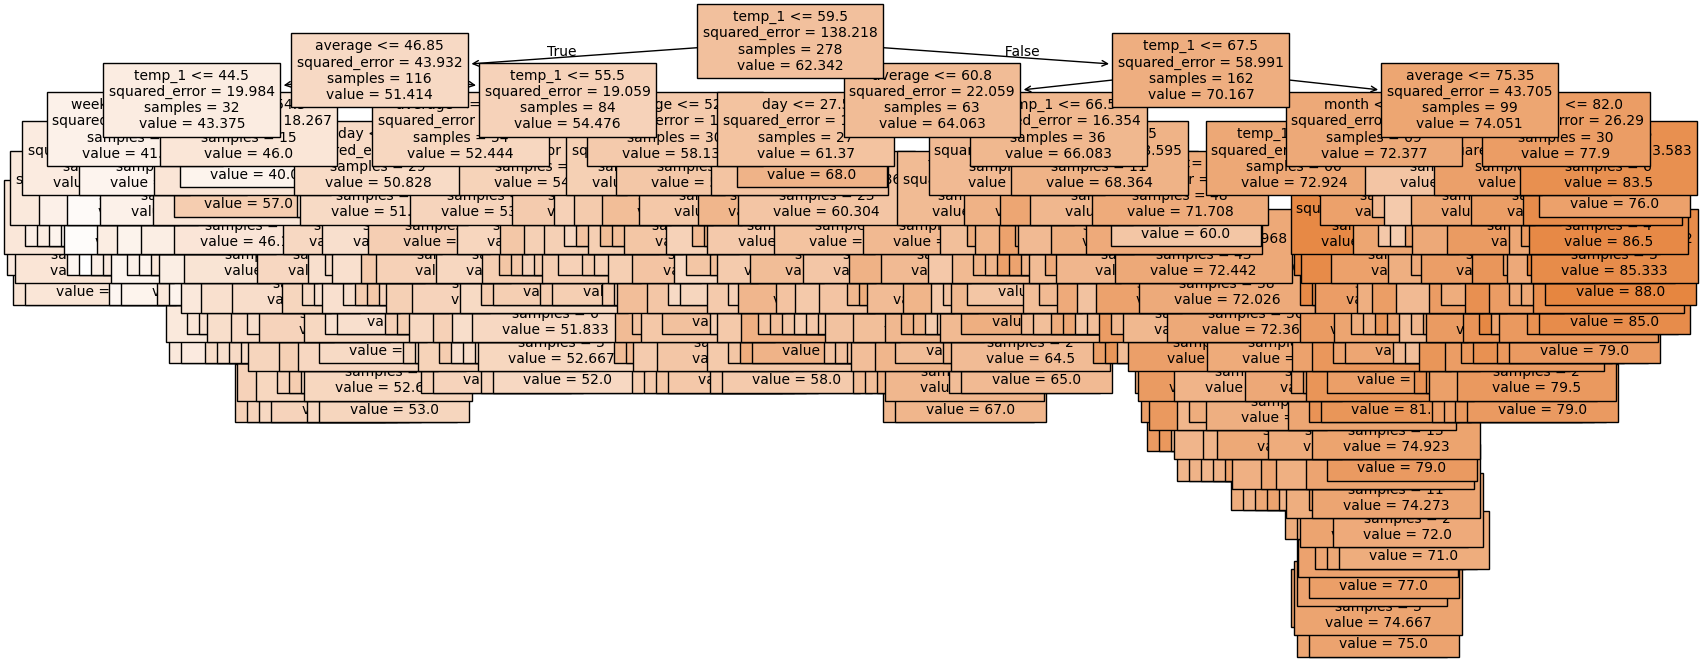

In [65]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,8))
plot_tree(tree_reg, fontsize=10, feature_names=X_train.columns, filled=True);

### 7. Modifica el max_depth a 3 y vuelve a entrenarlo

In [66]:
tree_reg3 = DecisionTreeRegressor(max_depth=3)
tree_reg3.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

### 8. Vuelve a evaluar tu modelo

In [67]:
y_pred = tree_reg3.predict(X_test)

print("R2 train", tree_reg3.score(X_train, y_train))
print("R2 test", tree_reg3.score(X_test, y_test))
print("MAE", mean_absolute_error(y_test, y_pred))
print("MAPE", mean_absolute_percentage_error(y_test, y_pred))
print("MSE", mean_squared_error(y_test, y_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 train 0.8397458755018086
R2 test 0.7786776796296856
MAE 4.267242249556827
MAPE 0.0674392768128964
MSE 30.946461197509944
RMSE 5.5629543587476915


### 9. Vuelve a representar su árbol

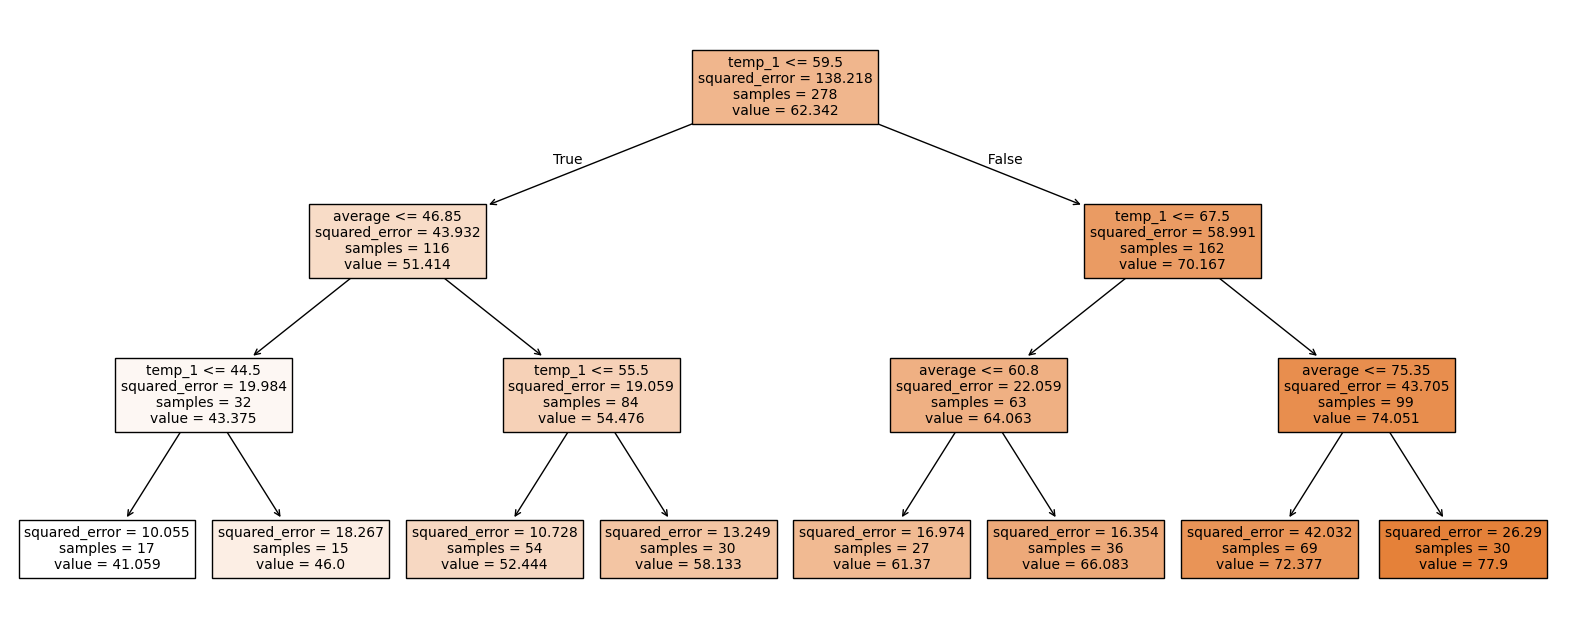

In [68]:
plt.figure(figsize=(20,8))
plot_tree(tree_reg3, fontsize=10, feature_names=X_train.columns, filled=True);

### 10. Utiliza un grid search con cross validation para hiperparametrizar tu modelo

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_leaf': [4, 5, 6, 7, 10, 15, 20],
    'min_samples_split': [15, 20, 25, 50]
}

grid_search = GridSearchCV(estimator=tree_reg,
                           param_grid=param_grid,
                           cv=5,
                           scoring="neg_mean_squared_error",
                           n_jobs=-1
                           )

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print('Mejores hiperparam:', grid_search.best_params_)
print('Mejor score:', grid_search.best_score_)

Mejores hiperparámetros: {'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 25}
Mejor score: -28.594549347960037


In [70]:
best_gs = grid_search.best_estimator_

In [71]:
y_pred = best_gs.predict(X_test)

print("MAE", mean_absolute_error(y_test, y_pred))
print("MAPE", mean_absolute_percentage_error(y_test, y_pred))
print("MSE", mean_squared_error(y_test, y_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE 3.752619628712729
MAPE 0.05993153951020385
MSE 23.528933039948996
RMSE 4.850663154657206


### 11. Obten el `feature_importances` de cada variable en el último modelo

In [72]:
importances = tree_reg3.feature_importances_

pd.DataFrame({'feature': X.columns,'importance': importances}).sort_values("importance", ascending=False)

,feature,importance
0,temp_1,0.881109
2,average,0.118891
1,temp_2,0.000000
3,friend,0.000000
4,month,0.000000
5,day,0.000000
6,week_num,0.000000
7,friend,0.000000


Parece que lo más importante a la hora de predecir es la temperatura del día anterior.

### 12. Construye un nuevo modelo `DecisionTreeClassifier` que te clasifique cuando en un día va a hacer una temperatura mayor a 15ºC (59ºF). ¡Deberá tratarse como un problema de **clasificación**! Utiliza un grid search con cross validation y evalúa el mejor modelo.

In [86]:
df['temp_59'] = np.where(df['actual']>59, 1, 0)
df.head()

,year,month,day,week,temp_2,temp_1,average,actual,friend,week_num,temp_59
0,2016,1,1,Fri,45,45,45.6,45,29,5,0
1,2016,1,2,Sat,44,45,45.7,44,61,6,0
2,2016,1,3,Sun,45,44,45.8,41,56,7,0
3,2016,1,4,Mon,44,41,45.9,40,53,1,0
4,2016,1,5,Tues,41,40,46.0,44,41,2,0


In [87]:
X_C = df[['temp_1', 'average']] # Los feature importantes
y_C = df['temp_59']

X_trainC, X_testC, y_trainC, y_testC = train_test_split(X_C, y_C, test_size=0.2, random_state=42)

print(X_trainC.shape)
print(X_testC.shape)
print(y_trainC.shape)
print(y_testC.shape)

(278, 2)
(70, 2)
(278,)
(70,)


In [88]:
from sklearn.tree import DecisionTreeClassifier

tree_class = DecisionTreeClassifier()
tree_class.fit(X_trainC, y_trainC)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [96]:
# Hiperparametrizamos de nuevo

from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_leaf': [4, 5, 6, 7, 10, 15, 20],
    'min_samples_split': [15, 20, 25, 50]
}

grid_search = GridSearchCV(estimator=tree_class,
                           param_grid=param_grid,
                           cv=5,
                           scoring="accuracy",
                           n_jobs=-1
                           )

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print('Mejores hiperparam:', grid_search.best_params_)
print('Mejor score:', grid_search.best_score_)

c:\Users\urkow\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Mejores hiperparam: {'max_depth': 5, 'min_samples_leaf': 7, 'min_samples_split': 15}
Mejor score: 0.12967532467532467


In [ ]:
best_gsC = grid_search.best_estimator_

In [97]:
y_predC = best_gsC.predict(X_testC)

print("MAE", mean_absolute_error(y_testC, y_predC))
print("MAPE", mean_absolute_percentage_error(y_testC, y_predC))
print("MSE", mean_squared_error(y_testC, y_predC))
print("RMSE", np.sqrt(mean_squared_error(y_testC, y_predC)))

NameError: name 'best_gsC' is not defined

No entiendo qué me está fallando... Algo se me escapa